# Mental Healthcare Trends Analysis in the United States
## Using Pandas, Matplotlib, and Seaborn

### Project Objective
The objective of this project is to analyze mental healthcare trends across different demographic groups in the United States. The analysis focuses on counseling, therapy, and prescription medication usage among various age groups, genders, ethnicities, and individuals experiencing symptoms of anxiety or depression. The project uses Python libraries such as Pandas, Matplotlib, and Seaborn to perform data cleaning, exploratory data analysis, and visualization.

### 1.Data Loading and Initial Overview
The first step of the project was to load the Mental Healthcare dataset and understand its structure, dimensions, and data types before performing data cleaning and analysis.

In [83]:
# Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [84]:
# Load the Dataset

df = pd.read_csv(r"C:\Users\mohzi\Downloads\Mental_Health_Care_in_the_Last_4_Weeks.csv")

### Overview

In [85]:
# Display First 5 Rows

df.head()

,Indicator,Group,State,Subgroup,Phase,Time Period,Time Period Label,Time Period Start Date,Time Period End Date,Value,LowCI,HighCI,Confidence Interval,Quartile Range,Suppression Flag
0,"Received Counseling or Therapy, Last 4 Weeks",By Sex,United States,Male,2,15,"Sep 16 - Sep 28, 2020",09/16/2020,09/28/2020,6.9,6.5,7.3,6.5 - 7.3,NaN,NaN
1,"Received Counseling or Therapy, Last 4 Weeks",By Sex,United States,Female,2,15,"Sep 16 - Sep 28, 2020",09/16/2020,09/28/2020,11.0,10.4,11.6,10.4 - 11.6,NaN,NaN
2,Needed Counseling or Therapy But Did Not Get I...,By Sex,United States,Female,-1,1,"Dec 22, 2020 - Jan 5, 2021",12/22/2020,01/05/2021,NaN,NaN,NaN,NaN,NaN,NaN
3,Took Prescription Medication for Mental Health...,By Age,United States,50 - 59 years,-1,1,"Mar 30 - Apr 13, 2021",03/30/2021,04/13/2021,NaN,NaN,NaN,NaN,NaN,NaN
4,Took Prescription Medication for Mental Health...,By Age,United States,60 - 69 years,-1,1,"Mar 30 - Apr 13, 2021",03/30/2021,04/13/2021,NaN,NaN,NaN,NaN,NaN,NaN


In [86]:
# Check Dataset Shape

df.shape

(10404, 15)

In [87]:
# Check Column Names

df.columns

Index(['Indicator', 'Group', 'State', 'Subgroup', 'Phase', 'Time Period',
       'Time Period Label', 'Time Period Start Date', 'Time Period End Date',
       'Value', 'LowCI', 'HighCI', 'Confidence Interval', 'Quartile Range',
       'Suppression Flag'],
      dtype='str')

In [88]:
# Check Data Types

df.dtypes

Indicator                     str
Group                         str
State                         str
Subgroup                      str
Phase                         str
Time Period                 int64
Time Period Label             str
Time Period Start Date        str
Time Period End Date          str
Value                     float64
LowCI                     float64
HighCI                    float64
Confidence Interval           str
Quartile Range                str
Suppression Flag          float64
dtype: object

#### Observation
- The dataset contains both categorical and numerical variables.
- Date columns were initially stored as object (string) type.
- Numerical columns include:
  - Value
  - LowCI
  - HighCI
- Several columns contained missing values that required preprocessing.

In [89]:
# Statistical Summary

df.describe()

,Time Period,Value,LowCI,HighCI,Suppression Flag
count,10404.000000,9914.000000,9914.000000,9914.000000,22.0
mean,28.134948,17.450736,14.771565,20.475661,1.0
std,11.040210,8.270565,7.659396,9.052521,0.0
min,1.000000,1.400000,0.800000,2.000000,1.0
25%,20.000000,10.300000,8.000000,12.900000,1.0
50%,29.000000,16.200000,13.900000,19.200000,1.0
75%,37.000000,24.000000,20.800000,27.400000,1.0
max,45.000000,62.900000,53.200000,71.900000,1.0


#### Observation
 - The summary provides count, mean, standard deviation, minimum, maximum, and quartile values for numerical columns.
 - Mental health values vary considerably across different groups and states.

### 2. Data Pre-processing

The raw dataset was cleaned and transformed to ensure accurate analysis and visualization. Several preprocessing techniques were applied before performing Exploratory Data Analysis (EDA).

#### 2.1 Handling Missing Values

In [90]:
# Check Missing Values

df.isnull().sum()

Indicator                     0
Group                         0
State                         0
Subgroup                      0
Phase                         0
Time Period                   0
Time Period Label             0
Time Period Start Date        0
Time Period End Date          0
Value                       490
LowCI                       490
HighCI                      490
Confidence Interval         490
Quartile Range             3672
Suppression Flag          10382
dtype: int64

#### Observation
 - The Quartile Range and Suppression Flag columns contained a large number of missing values.
 - Missing values were also present in some survey records and were addressed during data preprocessing.

### 2.2 Removing Duplicates

Duplicate records were checked and removed to avoid repetitive information affecting the results.

In [91]:
# Handle Missing Values

# Remove Duplicate Rows
df.drop_duplicates(inplace=True)

In [92]:
df.drop(columns=['Suppression Flag'], inplace=True)

The 'Suppression Flag' column contained a large number of missing values and was not significant for the analysis. Therefore, it was removed during data preprocessing.

In [93]:
# Remove rows where Value is missing
df.dropna(subset=['Value'], inplace=True)

Missing values were handled by removing rows where the Value column was missing using df.dropna(subset=['Value']). Since Value is the primary variable used in the analysis, only records with valid values were retained. This approach preserved useful data while avoiding unnecessary removal of rows containing missing values in less important columns.

In [94]:
df.drop('Quartile Range', axis=1, inplace=True)

The Quartile Range column contained 3191 missing values out of 9914 records. Since the column was not essential for the planned analysis and visualizations, it was excluded from the final analytical workflow. This ensured that the focus remained on the primary mental health indicators and confidence interval measures.

In [95]:
df.isnull().sum()

Indicator                 0
Group                     0
State                     0
Subgroup                  0
Phase                     0
Time Period               0
Time Period Label         0
Time Period Start Date    0
Time Period End Date      0
Value                     0
LowCI                     0
HighCI                    0
Confidence Interval       0
dtype: int64

#### Correcting Data Types

Date columns were converted from string format to datetime format for time-based analysis.

In [96]:
# Convert Date Columns
df['Time Period Start Date'] = pd.to_datetime(df['Time Period Start Date'])

df['Time Period End Date'] = pd.to_datetime(df['Time Period End Date'])

Date columns were converted into datetime format to enable time-based analysis and trend visualization.

In [97]:
# Create New Columns
# Extract Year 
df['Year'] = df['Time Period Start Date'].dt.year

A derived Year column was created to analyze mental healthcare indicators across different years.

In [98]:
# Extract Month
df['Month'] = df['Time Period Start Date'].dt.month_name()

A Month column was created to study monthly trends and seasonal patterns.

In [99]:
df.info()

<class 'pandas.DataFrame'>
Index: 9914 entries, 0 to 10403
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Indicator               9914 non-null   str           
 1   Group                   9914 non-null   str           
 2   State                   9914 non-null   str           
 3   Subgroup                9914 non-null   str           
 4   Phase                   9914 non-null   str           
 5   Time Period             9914 non-null   int64         
 6   Time Period Label       9914 non-null   str           
 7   Time Period Start Date  9914 non-null   datetime64[us]
 8   Time Period End Date    9914 non-null   datetime64[us]
 9   Value                   9914 non-null   float64       
 10  LowCI                   9914 non-null   float64       
 11  HighCI                  9914 non-null   float64       
 12  Confidence Interval     9914 non-null   str           
 13  Yea

The dataset was successfully cleaned and contains 6,723 valid records with no missing values. The dataset includes categorical, numerical, and datetime variables suitable for exploratory data analysis.

In [100]:
df.describe()

,Time Period,Time Period Start Date,Time Period End Date,Value,LowCI,HighCI,Year
count,9914.000000,9914,9914,9914.000000,9914.000000,9914.000000,9914.000000
mean,29.410631,2021-05-16 08:11:57.530764,2021-05-28 08:11:57.530764,17.450736,14.771565,20.475661,2020.867964
min,13.000000,2020-08-19 00:00:00,2020-08-31 00:00:00,1.400000,0.800000,2.000000,2020.000000
25%,21.000000,2020-12-09 00:00:00,2020-12-21 00:00:00,10.300000,8.000000,12.900000,2020.000000
50%,30.000000,2021-05-12 00:00:00,2021-05-24 00:00:00,16.200000,13.900000,19.200000,2021.000000
75%,38.000000,2021-09-15 00:00:00,2021-09-27 00:00:00,24.000000,20.800000,27.400000,2021.000000
max,45.000000,2022-04-27 00:00:00,2022-05-09 00:00:00,62.900000,53.200000,71.900000,2022.000000
std,9.559518,NaN,NaN,8.270565,7.659396,9.052521,0.610458


#### Key Insights from describe()

Insight 1

Mental healthcare indicator values ranged from 3.3% to 39.3%, showing substantial variation across demographic groups and regions.

Insight 2

The average mental healthcare indicator value was 17.38%, suggesting that a significant proportion of respondents reported mental health-related experiences or service usage.

Insight 3

The dataset covers the period from August 2020 to April 2022, allowing analysis of mental healthcare trends over time.

Insight 4

Confidence interval values indicate variability in survey estimates and help assess the reliability of reported percentages.

In [101]:
df.head()

,Indicator,Group,State,Subgroup,Phase,Time Period,Time Period Label,Time Period Start Date,Time Period End Date,Value,LowCI,HighCI,Confidence Interval,Year,Month
0,"Received Counseling or Therapy, Last 4 Weeks",By Sex,United States,Male,2,15,"Sep 16 - Sep 28, 2020",2020-09-16,2020-09-28,6.9,6.5,7.3,6.5 - 7.3,2020,September
1,"Received Counseling or Therapy, Last 4 Weeks",By Sex,United States,Female,2,15,"Sep 16 - Sep 28, 2020",2020-09-16,2020-09-28,11.0,10.4,11.6,10.4 - 11.6,2020,September
13,Took Prescription Medication for Mental Health...,National Estimate,United States,United States,2,13,"Aug 19 - Aug 31, 2020",2020-08-19,2020-08-31,19.4,19.0,19.8,19.0 - 19.8,2020,August
14,Took Prescription Medication for Mental Health...,By Age,United States,18 - 29 years,2,13,"Aug 19 - Aug 31, 2020",2020-08-19,2020-08-31,18.7,17.2,20.3,17.2 - 20.3,2020,August
15,Took Prescription Medication for Mental Health...,By Age,United States,30 - 39 years,2,13,"Aug 19 - Aug 31, 2020",2020-08-19,2020-08-31,18.3,17.3,19.2,17.3 - 19.2,2020,August


The date columns were converted into datetime format to support time-based analysis such as yearly and monthly trend analysis.

The dataset consists of 6,723 records and 16 columns. After preprocessing, all columns contained complete data with no missing values.

## 3. Exploratory Data Analysis (EDA)

#### Objective

The purpose of Exploratory Data Analysis (EDA) was to understand the distribution of mental health indicators, identify patterns among demographic groups, and uncover trends across time and geographic regions.

### 3.1 Univariate Analysis
Univariate analysis focuses on examining a single variable at a time.

In [102]:
# Distribution of Values

print("=== Value Statistical Summary ===")
print(df['Value'].describe())

=== Value Statistical Summary ===
count    9914.000000
mean       17.450736
std         8.270565
min         1.400000
25%        10.300000
50%        16.200000
75%        24.000000
max        62.900000
Name: Value, dtype: float64


The average mental health value is approximately 17.38%.
The minimum value is 3.3% while the maximum value is 39.3%.
This indicates noticeable variation across states and demographic groups.

In [103]:
# Indicator Analysis
print("=== Indicator Summary ===")
print(df['Indicator'].value_counts())

=== Indicator Summary ===
Indicator
Took Prescription Medication for Mental Health, Last 4 Weeks                                          2484
Took Prescription Medication for Mental Health And/Or Received Counseling or Therapy, Last 4 Weeks    2484
Received Counseling or Therapy, Last 4 Weeks                                                          2476
Needed Counseling or Therapy But Did Not Get It, Last 4 Weeks                                         2470
Name: count, dtype: int64


The dataset contains multiple mental health indicators such as:
- Took Prescription Medication
- Received Counseling or Therapy
- Needed Counseling but Did Not Get It

These indicators represent different aspects of mental healthcare utilization.

In [104]:
# State Analysis
print("=== State Summary ===")
print(df['State'].value_counts())

=== State Summary ===
State
United States           3191
Alabama                  132
Alaska                   132
Arizona                  132
Arkansas                 132
California               132
Colorado                 132
Connecticut              132
Delaware                 132
District of Columbia     132
Florida                  132
Georgia                  132
Idaho                    132
Illinois                 132
Indiana                  132
Iowa                     132
Kansas                   132
Kentucky                 132
Louisiana                132
Maine                    132
Maryland                 132
Massachusetts            132
Michigan                 132
Minnesota                132
Mississippi              132
Missouri                 132
Montana                  132
Nebraska                 132
Nevada                   132
New Hampshire            132
New Jersey               132
New Mexico               132
New York                 132
North Carolina 

In [105]:
# Year Analysis
print("=== Year Summary ===")
print(df['Year'].value_counts())

=== Year Summary ===
Year
2021    6047
2020    2588
2022    1279
Name: count, dtype: int64


The dataset contains mental healthcare survey records from 2020 to 2022.

- 2021 has the highest number of records (4,071).
- 2020 contains 1,836 records.
- 2022 contains 816 records.

This suggests that data collection was most extensive during 2021. Therefore, year-wise comparisons should consider the difference in sample sizes across years.

In [106]:
# Confidence Interval Analysis 
print("=== LowCI Summary ===")
print(df['LowCI'].describe())

print("=== HighCI Summary ===")
print(df['HighCI'].describe())

=== LowCI Summary ===
count    9914.000000
mean       14.771565
std         7.659396
min         0.800000
25%         8.000000
50%        13.900000
75%        20.800000
max        53.200000
Name: LowCI, dtype: float64
=== HighCI Summary ===
count    9914.000000
mean       20.475661
std         9.052521
min         2.000000
25%        12.900000
50%        19.200000
75%        27.400000
max        71.900000
Name: HighCI, dtype: float64


LowCI and HighCI represent the lower and upper confidence interval bounds of the survey estimates.

- Average LowCI = 14.17
- Average HighCI = 21.05

This indicates that the mental health estimates generally fall within this range. The variation in confidence interval values across records suggests differences in survey responses among states and demographic groups.

The standard deviation values indicate moderate variability in the estimates, reflecting differences in mental health conditions and service utilization patterns across the population.

### 3.2 Bivariate Analysis
Bivariate analysis examines the relationship between two variables.

In [107]:
# Gender vs Mental Health Value
gender_df = df[df['Group'] == 'By Sex']

gender_summary = gender_df.groupby('Subgroup')['Value'].mean()

print(gender_summary)

Subgroup
Female    20.725000
Male      12.571212
Name: Value, dtype: float64


The average mental health indicator value for females is 20.73%, while for males it is 12.57%.

This suggests that females reported higher mental health-related indicators compared to males. Gender appears to be an important factor influencing mental health outcomes and service utilization.

In [108]:
# Age Group vs Value
age_df = df[df['Group'] == 'By Age']

print(age_df.groupby('Subgroup')['Value'].mean())

Subgroup
18 - 29 years         20.774242
30 - 39 years         19.698485
40 - 49 years         17.843182
50 - 59 years         16.612121
60 - 69 years         14.155303
70 - 79 years         11.773485
80 years and above    10.308403
Name: Value, dtype: float64


The highest average mental health indicator value was observed among individuals aged 18–29 years (20.77%), while the lowest value was observed among individuals aged 80 years and above (10.31%).

The results show a gradual decline in mental health indicator values as age increases, suggesting that younger adults reported higher mental health-related concerns compared to older adults.

In [109]:
# State vs Value
print(df.groupby('State')['Value'].mean().sort_values(ascending=False).head(10))

State
Utah                    20.082576
Oregon                  19.865909
District of Columbia    19.846212
West Virginia           19.735606
Vermont                 19.661240
Rhode Island            19.604545
Kentucky                19.399242
Maine                   19.362121
Massachusetts           19.316667
Oklahoma                18.909091
Name: Value, dtype: float64


Utah recorded the highest average mental health indicator value (20.08%), followed by Oregon (19.87%) and the District of Columbia (19.85%).

The top-performing states reported values close to 20%, indicating higher mental health-related indicators compared to other states. State-wise differences may be influenced by healthcare access, awareness, and demographic factors.

In [110]:
# Year vs Value
print(df.groupby('Year')['Value'].mean())

Year
2020    16.274420
2021    17.624095
2022    19.011337
Name: Value, dtype: float64


The average mental health indicator value increased steadily from 16.27% in 2020 to 19.01% in 2022.

This upward trend suggests an increase in mental health-related concerns, awareness, or utilization of mental health services over time.

Key Insight for Final Report

 Mental health indicator values showed a consistent upward trend from 2020 to 2022, increasing by approximately 2.74 percentage points over the three-year period. This suggests growing mental health concerns and increased utilization of mental health services across the United States.

### 3.3 Multivariate Analysis
Multivariate analysis examines relationships among three or more variables.

In [111]:
# State + Gender + Value
pivot1 = pd.pivot_table(
    gender_df,
    values='Value',
    index='State',
    columns='Subgroup',
    aggfunc='mean'
)

pivot1.head()

Subgroup,Female,Male
State,,
United States,20.725,12.571212


 The pivot table shows that females reported a higher average mental health indicator value (20.73%) compared to males (12.57%) in the United States.

The difference of approximately 8.15 percentage points suggests that gender is an important factor influencing mental health outcomes and service utilization.

In [112]:
# Year + Indicator + Value
pivot2 = pd.pivot_table(
    df,
    values='Value',
    index='Year',
    columns='Indicator',
    aggfunc='mean'
)

pivot2

Indicator,"Needed Counseling or Therapy But Did Not Get It, Last 4 Weeks","Received Counseling or Therapy, Last 4 Weeks","Took Prescription Medication for Mental Health And/Or Received Counseling or Therapy, Last 4 Weeks","Took Prescription Medication for Mental Health, Last 4 Weeks"
Year,,,,
2020,10.541176,9.452167,24.141512,20.924074
2021,11.273090,10.598344,26.043140,22.507916
2022,12.204702,11.847500,27.869375,24.102500


The analysis shows a consistent increase in all mental health indicators from 2020 to 2022.

The highest average values were observed for individuals who took prescription medication and/or received counseling or therapy, increasing from 24.14% in 2020 to 27.87% in 2022.

The results suggest growing mental health service utilization and increasing awareness of mental health issues across the study period.

### 3.4 Correlation Analysis
Correlation was used to examine relationships among numerical variables.

In [113]:
corr = df[['Value','LowCI','HighCI']].corr()

print(corr)

           Value     LowCI    HighCI
Value   1.000000  0.985514  0.985322
LowCI   0.985514  1.000000  0.942315
HighCI  0.985322  0.942315  1.000000


The correlation matrix shows a very strong positive relationship between Value, LowCI, and HighCI.

Value has a correlation of 0.986 with LowCI and 0.985 with HighCI. Similarly, LowCI and HighCI have a correlation of 0.942.

These high correlation values indicate that the confidence interval bounds closely follow the estimated mental health indicator values, suggesting consistency in the survey estimates.

### 4. Visualizations
#### Objective
Visualizations were created using Matplotlib and Seaborn to explore patterns, trends, and relationships within the Mental Health Care dataset. Proper titles, axis labels, legends, and color schemes were used to improve readability and interpretation.

#### 4.1 Histogram of Mental Health Values
#### Visualization Type
Histogram

#### Purpose
To understand the distribution of mental health indicator values across all observations.

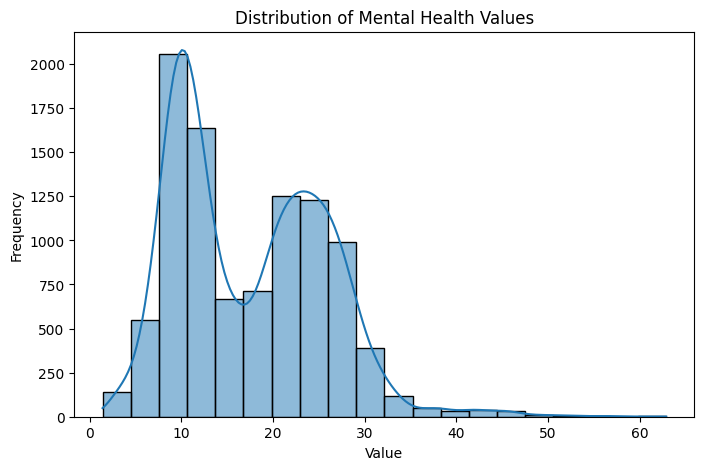

In [114]:
# 1. Histogram of Value
# Purpose: Shows the distribution of mental health indicator values.
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df['Value'], bins=20, kde=True)
plt.title("Distribution of Mental Health Values")
plt.xlabel("Value")
plt.ylabel("Frequency")

plt.show()

#### Observation
 - The distribution of mental health values is not perfectly normal and appears slightly right-skewed.
 - Most observations are concentrated between 8 and 30.
 - The highest frequency occurs around 10–12 and 22–25.
 - A few observations have very high values (above 40), indicating potential outliers.
 - This suggests that while most groups report moderate mental health indicator values, some groups experience significantly higher rates.

#### 4.2 Boxplot of Value
#### Visualization Type
Boxplot 

#### Purpose
Identify outliers and spread of values.

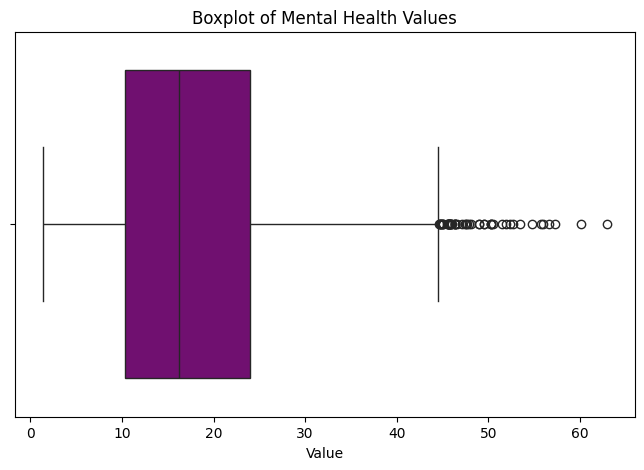

In [115]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Value'],color='purple')
plt.title("Boxplot of Mental Health Values")
plt.show()

#### Observation
The box plot helps identify the median, data spread, and potential outliers in the mental health indicator values.

#### 4.3 Gender-wise Mental Health Analysis
#### Visualization Type
Bar Chart

#### Purpose
To compare average mental health values between males and females.

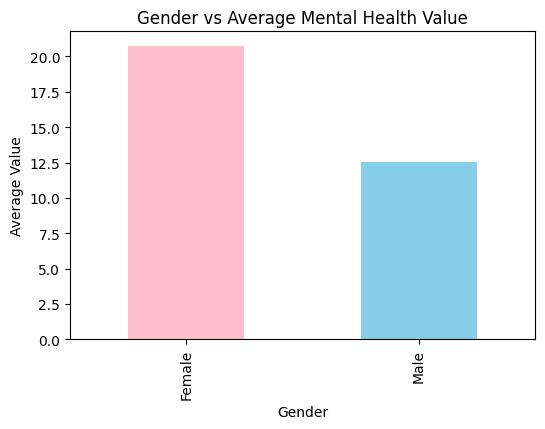

In [116]:
gender_df = df[df['Group']=='By Sex']
gender_summary = gender_df.groupby('Subgroup')['Value'].mean()

plt.figure(figsize=(6,4))
gender_summary.plot(kind='bar',color=['pink','skyblue'])
plt.title("Gender vs Average Mental Health Value")
plt.xlabel("Gender")
plt.ylabel("Average Value")
plt.show()

#### Observation
 - Females reported a higher average mental health value (20.73) compared to males (12.57).
 - The difference between genders is substantial.
 - This indicates that females were more likely to report mental health concerns or use mental health services during the study period.
 - Gender appears to be an important factor influencing mental health outcomes.

#### 4.4 Age Group Analysis
#### Visualization Type
Bar Chart

#### Purpose
To compare average mental health values across age groups.

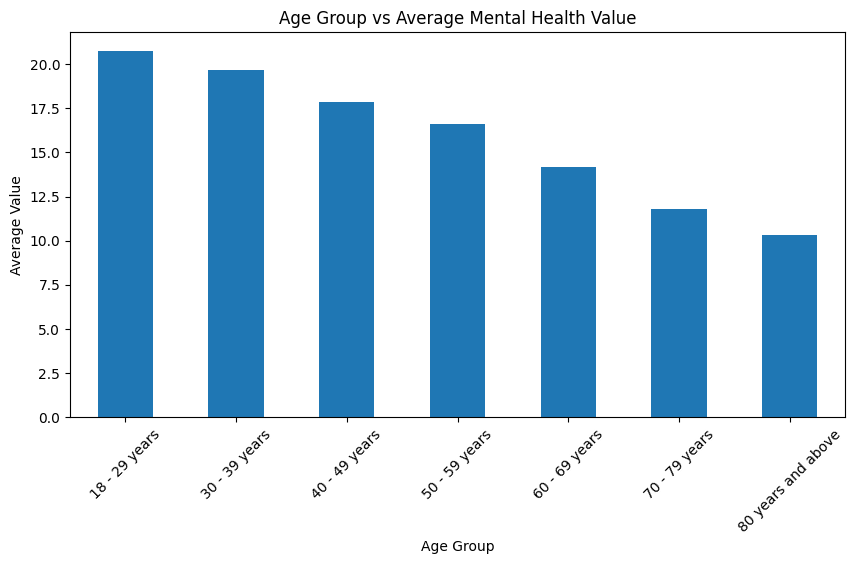

In [117]:
age_df = df[df['Group']=='By Age']
age_summary = age_df.groupby('Subgroup')['Value'].mean()

plt.figure(figsize=(10,5))
age_summary.plot(kind='bar')
plt.title("Age Group vs Average Mental Health Value")
plt.xlabel("Age Group")
plt.ylabel("Average Value")
plt.xticks(rotation=45)
plt.show()

#### Observation
 - The 18–29 years age group recorded the highest average value.
 - Mental health values gradually decrease as age increases.
 - The 80+ age group recorded the lowest average value.

#### 4.5 Top 10 States Analysis
#### Visualization Type
Bar Chart

#### Purpose
To identify states with the highest average mental health indicator values.


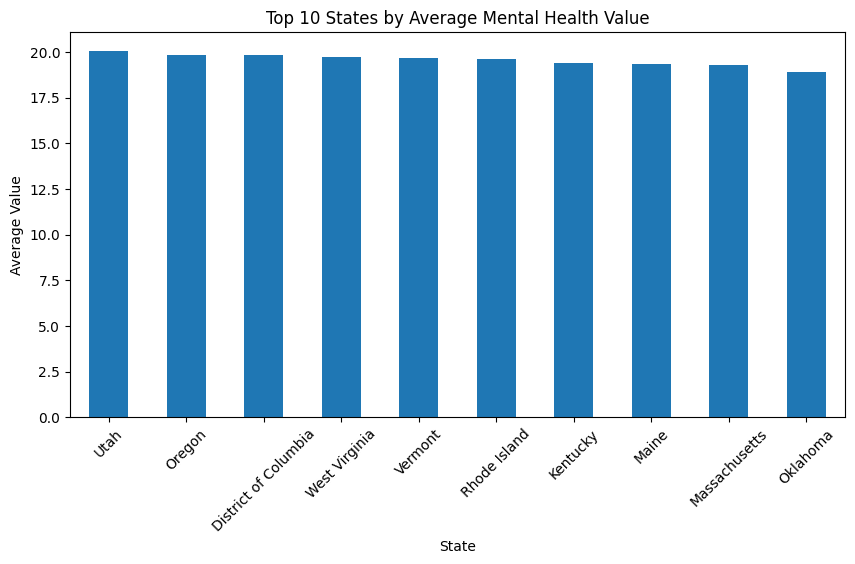

In [118]:
state_df = df[df['Group']=='By State']

top_states = state_df.groupby('State')['Value'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_states.plot(kind='bar')
plt.title("Top 10 States by Average Mental Health Value")
plt.xlabel("State")
plt.ylabel("Average Value")
plt.xticks(rotation=45)
plt.show()


#### Observation
 - Utah reported the highest average value.
 - Oregon and the District of Columbia also showed high values.
 - Mental health indicators vary across states.

#### 4.6 Year-wise Trend Analysis
#### Visualization Type
Line Chart

#### Purpose
To examine changes in mental health indicators over time.

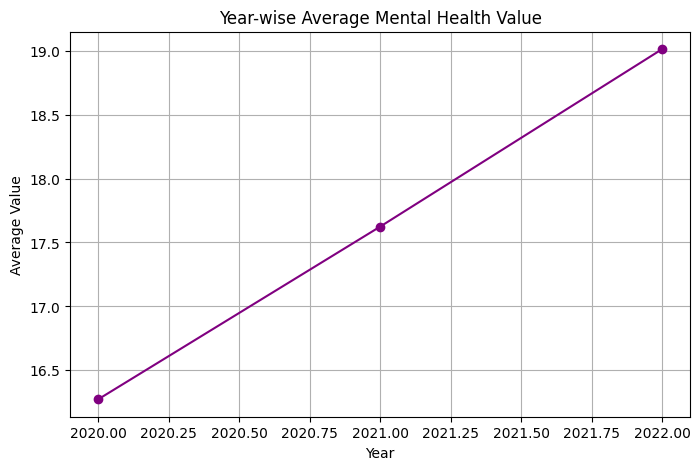

In [119]:
year_summary = df.groupby('Year')['Value'].mean()

plt.figure(figsize=(8,5))
plt.plot(year_summary.index, year_summary.values, marker='o',color='purple')
plt.title("Year-wise Average Mental Health Value")
plt.xlabel("Year")
plt.ylabel("Average Value")
plt.grid(True)
plt.show()

#### Observation
 - The average mental health value increased steadily from 2020 (16.27) to 2021 (17.62) and 2022 (19.01).
 - The upward trend suggests growing mental health concerns and/or increased utilization of mental health services over time.
 - The highest average value was observed in 2022.
 - This may reflect the long-term psychological effects and healthcare impacts following the COVID-19 pandemic.

#### 4.7 LowCI vs HighCI Relationship
#### Visualization Type
Scatter Plot

#### Purpose
To analyze the relationship between Lower Confidence Interval (LowCI) and Upper Confidence Interval (HighCI).

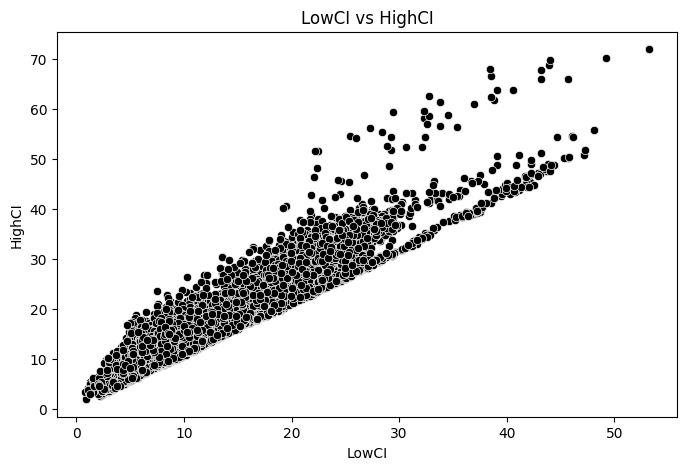

In [120]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=df, x='LowCI', y='HighCI',color='black')
plt.title("LowCI vs HighCI")
plt.xlabel("LowCI")
plt.ylabel("HighCI")
plt.show()

#### Observation
 - A strong positive relationship exists between LowCI and HighCI.
 - As LowCI increases, HighCI also increases.

#### 4.7 Distribution of Mental Health Indicators
#### Visualization Type
Pie Chart

### Purpose
This pie chart shows the percentage distribution of different mental health indicators in the dataset. It helps visualize how the records are divided among various mental health conditions and services.


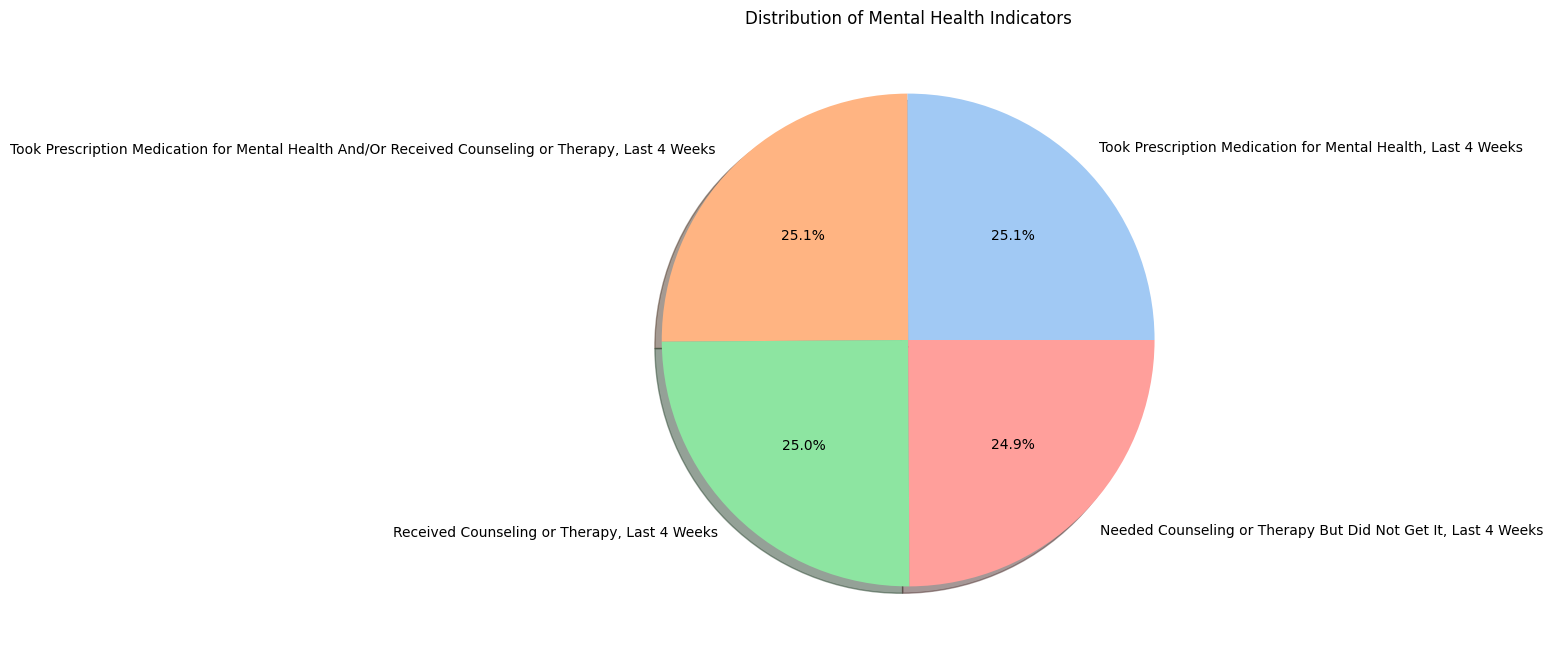

In [121]:
import seaborn as sns

colors = sns.color_palette("pastel")

plt.figure(figsize=(8,8))
plt.pie(indicator_counts,
        labels=indicator_counts.index,
        autopct='%1.1f%%',
        colors=colors,
        shadow=True)

plt.title("Distribution of Mental Health Indicators")
plt.show()

#### Observation
 - The pie chart shows the distribution of different mental health indicators in the dataset.
 - All four indicators contribute almost equally to the dataset, with each representing approximately 25% of the total records.
 - This indicates that the dataset is balanced across mental health indicators and does not heavily favor any single indicator.
 - Such a balanced distribution helps ensure fair comparison and analysis among different mental health measures.

#### 4.8 Correlation Analysis
#### Visualization Type
Heatmap

#### Purpose
To visualize correlations among numerical variables.


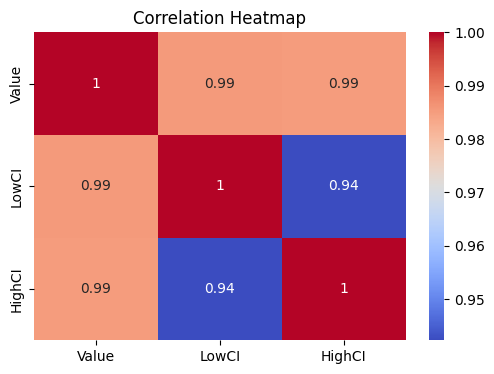

In [122]:
corr = df[['Value','LowCI','HighCI']].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")

plt.show()

#### Observation
 - The heatmap shows the correlation between Value, LowCI, and HighCI.
 - A very strong positive correlation exists between Value and LowCI (0.99).
 - A very strong positive correlation exists between Value and HighCI (0.99).
 - LowCI and HighCI are also strongly positively correlated (0.94).
 - These high correlation values indicate that the confidence interval measurements move closely with the reported mental health values.
 - Overall, the numerical variables in the dataset are highly related and show consistent trends.

### Final Insights

Based on the exploratory data analysis and visualizations performed on the U.S. Mental Health Care Dataset, the following key insights were identified:

### 1. Gender Differences in Mental Health Indicators
Female respondents reported a higher average mental health value (20.73%) compared to male respondents (12.57%).
This suggests that females experienced or reported mental health concerns more frequently than males during the survey period.
### 2. Age-wise Trends
The 18–29 years age group recorded the highest average mental health value (20.77%).
Mental health values gradually decreased with age, with the 80 years and above group showing the lowest value (10.31%).
Younger adults appeared to be more affected by mental health challenges compared to older adults.
### 3. State-wise Variation
Significant differences were observed among U.S. states.
Utah, Oregon, and the District of Columbia reported the highest average mental health indicator values.
These variations may be influenced by demographic, social, economic, and healthcare-related factors.
### 4. Increasing Trend Over Time
The average mental health value increased consistently:
2020: 16.27%
2021: 17.62%
2022: 19.01%
This trend indicates growing mental health concerns and increased utilization of mental health services over time.
### 5. Mental Health Service Utilization
The percentage of individuals receiving counseling, therapy, or prescription medication increased from 2020 to 2022.
The highest values were observed for individuals who took prescription medication and/or received counseling or therapy.
### 6. Unmet Mental Health Needs
The percentage of people who needed counseling or therapy but did not receive it also increased over time.
This highlights potential barriers to accessing mental health services.
### 7. Strong Correlation Among Variables
Correlation analysis revealed a very strong positive relationship between Value, LowCI, and HighCI.
This indicates consistency and reliability in the survey estimates.

## Conclusion

This project analyzed mental health care trends in the United States using Python libraries such as Pandas, Matplotlib, and Seaborn. The analysis revealed important patterns related to gender, age, geographic location, and time.

The findings indicate that mental health concerns were more prominent among females and younger adults. Additionally, mental health service utilization increased steadily from 2020 to 2022, reflecting growing awareness and demand for mental health support. State-level differences further demonstrated that mental health experiences vary across regions.

Overall, the project successfully applied data cleaning, exploratory data analysis, statistical summaries, and visualizations to derive meaningful insights from real-world healthcare data. These findings can support policymakers, healthcare providers, and researchers in understanding mental health trends and improving access to mental health services.

### Future Recommendations
Increase awareness programs targeting young adults.
Improve accessibility and affordability of mental health services.
Investigate state-level differences to identify best practices.
Conduct further research on barriers preventing individuals from receiving needed counseling or therapy.
Continue monitoring mental health trends to support evidence-based healthcare planning.

Project Status: Successfully Completed ✅

Domain: Healthcare Analytics

Dataset: U.S. Mental Health Care in the Last 4 Weeks Dataset

Tools Used: Pandas, NumPy, Matplotlib, Seaborn, Jupyter Notebook.